In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_045.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_005.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_103.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_019.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_078.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_021.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_084.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_012.jpg
/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_097.jpg
/kaggle/in

In [2]:
!pip install -q ultralytics openpyxl

import os
import json
import shutil
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
data_yaml_path = "/kaggle/input/datasets/yashbhakte/datset-label/Label Dataset/data.yaml"
excel_path = "/kaggle/input/datasets/yashbhakte/fabric-dd-reason-dataset/Fabric Defect ReasonMachineSuggestion Dataset.xlsx"


In [4]:
# detect_train_model = YOLO("yolo11n.pt")

# detect_train_model.train(
#     data=data_yaml_path,
#     epochs=50,
#     imgsz=640,
#     batch=16,
#     project="/kaggle/working",
#     name="yolo_fabric_detection"
# )


In [15]:
from ultralytics import YOLO

detect_model = YOLO("/kaggle/input/models/yashbhakte/detection-model-yolo/pytorch/default/1/det_best.pt")   # path where you saved it

In [16]:
metadata_df = pd.read_excel(excel_path)

def normalize_defect_name(name):
    return str(name).strip().lower().replace("-", " ")

mapping_data = {}

for _, row in metadata_df.iterrows():
    defect_name = normalize_defect_name(row["Defect Category"])

    mapping_data[defect_name] = {
        "reason_1": str(row.get("1st Priority (Most Likely)", "")),
        "reason_2": str(row.get("2nd Priority (Check Next )", "")),
        "reason_3": str(row.get("3rd Priority (Rare)", "")),
        "suggestion": str(row.get("Suggestion to reduce future defect", "")),
        "machine": str(row.get("Machine Responsible", ""))
    }

print("Mapping created successfully!")
print(json.dumps(mapping_data, indent=2))


Mapping created successfully!
{
  "stain": {
    "reason_1": "75%: Oil leakage from bearings/cams.",
    "reason_2": "20%: Dirt or sweat from manual handling.",
    "reason_3": "5%: Rust marks from old machine parts.",
    "suggestion": "Clean oil seals; enforce worker hand-hygiene protocols.",
    "machine": "Any Machine (Spinning/Loom)"
  },
  "hole": {
    "reason_1": "80%: Broken needle hook or sharp part.",
    "reason_2": "15%: Weak yarn snapping under tension.",
    "reason_3": "5%: Rough handling/snagging by worker.",
    "suggestion": "Inspect needle bed; replace dull hooks; test yarn strength.",
    "machine": "Knitting Machine / Power Loom"
  },
  "horizontal": {
    "reason_1": "70%: Yarn feeder timing or tension error.",
    "reason_2": "25%: Faulty Bobbin/Pirn tension.",
    "reason_3": "5%: Variation in yarn thickness (Count).",
    "suggestion": "Recalibrate feeder timing; check bobbin winding pressure.",
    "machine": "Circular / Shuttle Loom"
  },
  "vertical": {
   

In [17]:
def full_prediction_yolo_detection(img_path, conf_threshold=0.25):
    results = detect_model.predict(img_path, conf=conf_threshold, verbose=False)
    result = results[0]

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("===== FINAL RESULT =====")

    if len(result.boxes) == 0:
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title("No defect detected")
        plt.show()

        print("No defect detected.")
        return

    for i, box in enumerate(result.boxes, start=1):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])

        defect_name = result.names[cls_id]
        normalized_defect = normalize_defect_name(defect_name)

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            img_rgb,
            f"{defect_name} {conf:.2f}",
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

        info = mapping_data.get(normalized_defect, {})

        print(f"\nDetection {i}")
        print(f"Defect: {defect_name}")
        print(f"Confidence: {conf:.4f}")
        print(f"Bounding Box: x1={x1}, y1={y1}, x2={x2}, y2={y2}")
        print(f"Reason 1: {info.get('reason_1', 'Not available')}")
        print(f"Reason 2: {info.get('reason_2', 'Not available')}")
        print(f"Reason 3: {info.get('reason_3', 'Not available')}")
        print(f"Suggestion: {info.get('suggestion', 'Not available')}")
        print(f"Machine: {info.get('machine', 'Not available')}")

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Detected Defect with Bounding Box")
    plt.show()


===== FINAL RESULT =====

Detection 1
Defect: Pinched fabric
Confidence: 0.7801
Bounding Box: x1=39, y1=4, x2=146, y2=222
Reason 1: 75%: Uneven roller pressure.
Reason 2: 20%: Presser foot too tight.
Reason 3: 5%: Fabric fold during feeding process.
Suggestion: Recalibrate pneumatic roller pressure; adjust presser foot.
Machine: Inspection / Finishing Machine


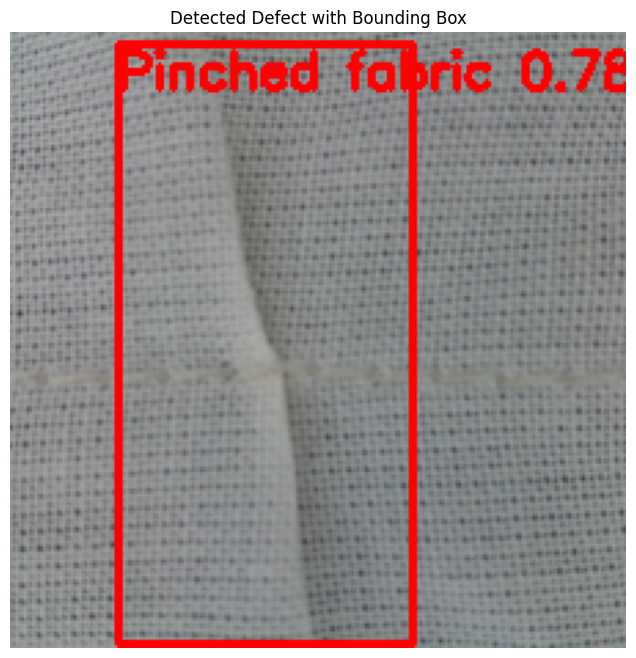

In [18]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_009.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Hole
Confidence: 0.5658
Bounding Box: x1=424, y1=145, x2=477, y2=216
Reason 1: 80%: Broken needle hook or sharp part.
Reason 2: 15%: Weak yarn snapping under tension.
Reason 3: 5%: Rough handling/snagging by worker.
Suggestion: Inspect needle bed; replace dull hooks; test yarn strength.
Machine: Knitting Machine / Power Loom

Detection 2
Defect: Hole
Confidence: 0.4257
Bounding Box: x1=420, y1=139, x2=483, y2=228
Reason 1: 80%: Broken needle hook or sharp part.
Reason 2: 15%: Weak yarn snapping under tension.
Reason 3: 5%: Rough handling/snagging by worker.
Suggestion: Inspect needle bed; replace dull hooks; test yarn strength.
Machine: Knitting Machine / Power Loom


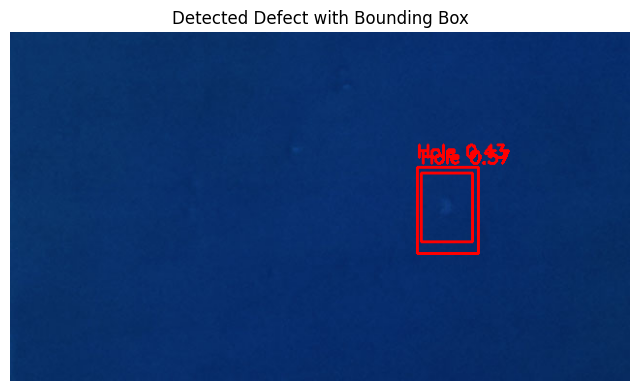

In [19]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/hole/13.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Stain
Confidence: 0.7675
Bounding Box: x1=196, y1=128, x2=769, y2=886
Reason 1: 75%: Oil leakage from bearings/cams.
Reason 2: 20%: Dirt or sweat from manual handling.
Reason 3: 5%: Rust marks from old machine parts.
Suggestion: Clean oil seals; enforce worker hand-hygiene protocols.
Machine: Any Machine (Spinning/Loom)

Detection 2
Defect: Stain
Confidence: 0.7572
Bounding Box: x1=1359, y1=361, x2=1885, y2=1022
Reason 1: 75%: Oil leakage from bearings/cams.
Reason 2: 20%: Dirt or sweat from manual handling.
Reason 3: 5%: Rust marks from old machine parts.
Suggestion: Clean oil seals; enforce worker hand-hygiene protocols.
Machine: Any Machine (Spinning/Loom)


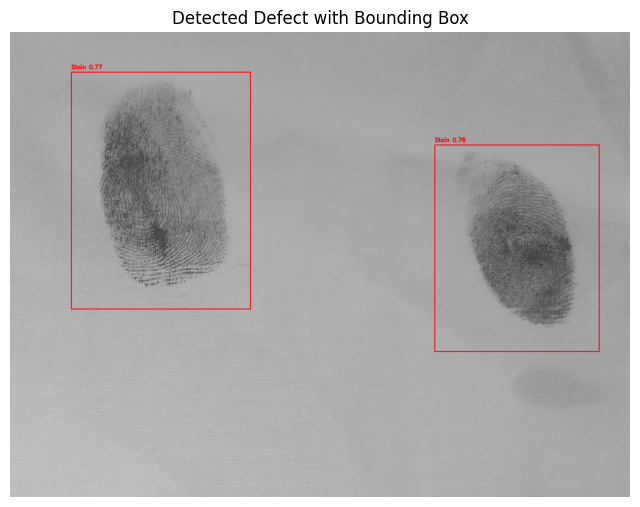

In [20]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/stain/11.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Broken stitch
Confidence: 0.7462
Bounding Box: x1=0, y1=81, x2=224, y2=155
Reason 1: 85%: High thread tension or timing error.
Reason 2: 10%: Machine running at "Over-Speed."
Reason 3: 5%: Blunt needle tip or low-quality thread.
Suggestion: Reset rotary hook timing; reduce RPM; adjust tensioner.
Machine: Sewing / Overlock Machine


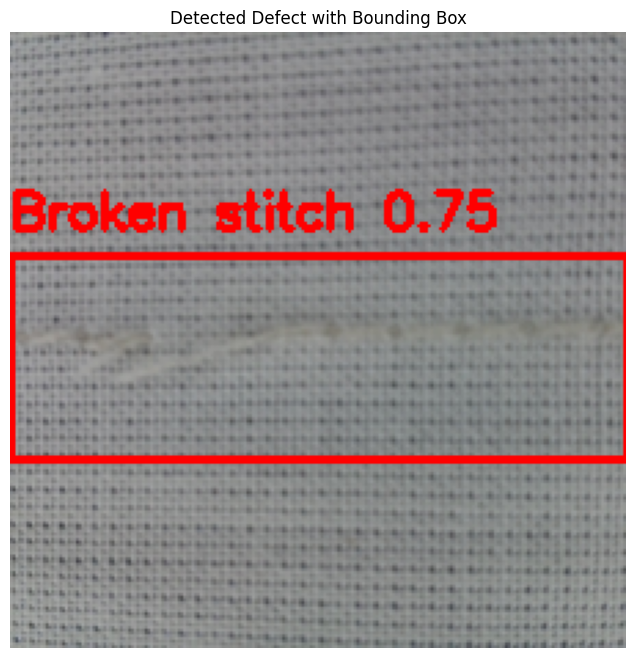

In [21]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Broken stitch/A_02_013.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Needle mark
Confidence: 0.7922
Bounding Box: x1=0, y1=96, x2=223, y2=160
Reason 1: 80%: Bent or damaged needle/latch.
Reason 2: 15%: Worn-out needle grooves.
Reason 3: 5%: Incorrect needle size for fabric weight.
Suggestion: Replace needles immediately; check latch movement/grooves.
Machine: Circular Knitting Machine


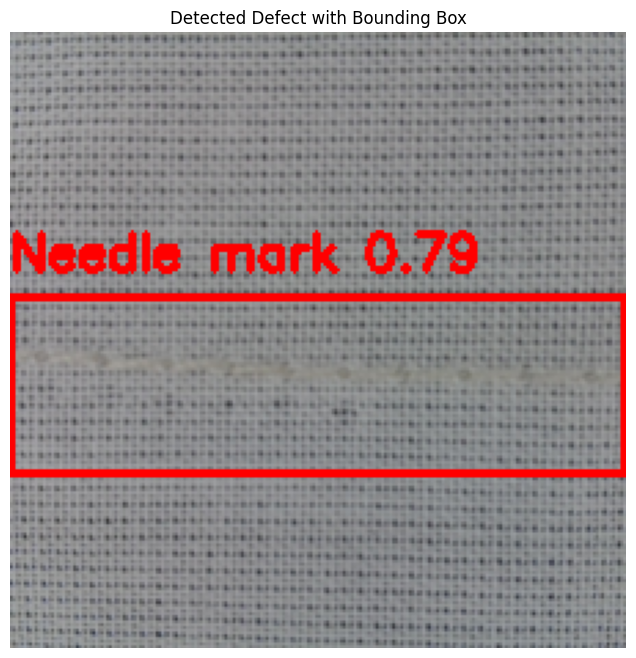

In [22]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Needle mark/A_08_011.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Vertical
Confidence: 0.4534
Bounding Box: x1=397, y1=166, x2=473, y2=359
Reason 1: 75%: Misaligned or damaged needle.
Reason 2: 20%: Sinker damage or warp thread missing.
Reason 3: 5%: Static buildup in the yarn path.
Suggestion: Align needle frame; check sinkers for metal burrs or lint.
Machine: Warp Knitting / Weaving Loom


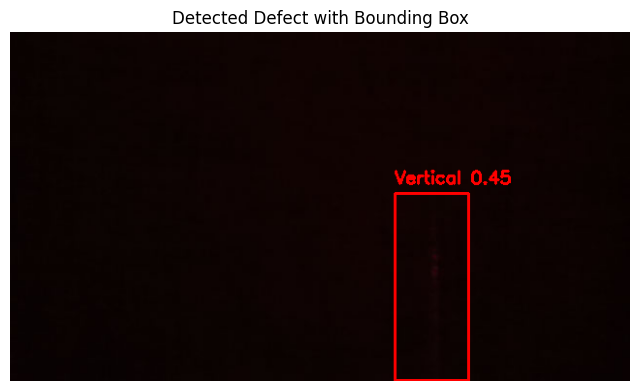

In [23]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Vertical/17.jpg"
)


===== FINAL RESULT =====


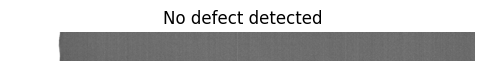

No defect detected.


In [24]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/defect free/0003_000_01.png"
)


===== FINAL RESULT =====

Detection 1
Defect: Horizontal
Confidence: 0.4858
Bounding Box: x1=0, y1=91, x2=626, y2=192
Reason 1: 70%: Yarn feeder timing or tension error.
Reason 2: 25%: Faulty Bobbin/Pirn tension.
Reason 3: 5%: Variation in yarn thickness (Count).
Suggestion: Recalibrate feeder timing; check bobbin winding pressure.
Machine: Circular / Shuttle Loom


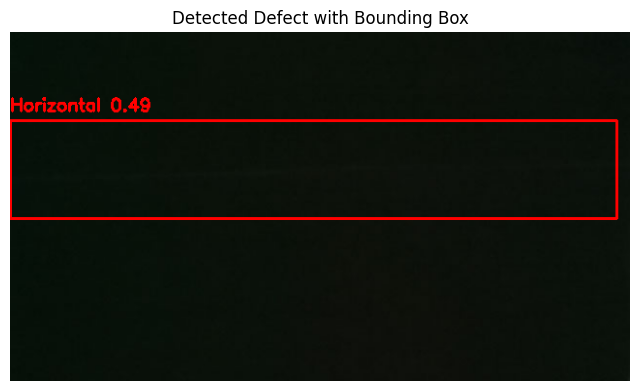

In [25]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/horizontal/16.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Lines
Confidence: 0.6651
Bounding Box: x1=1366, y1=0, x2=2088, y2=4590
Reason 1: 70%: Constant tension pulses/vibrations.
Reason 2: 25%: Yarn slubs or irregular thickness.
Reason 3: 5%: Rolling vibration in the machine frame.
Suggestion: Check machine mounting; stabilize tension rollers; check yarn.
Machine: Any High-Speed Machine

Detection 2
Defect: Lines
Confidence: 0.4477
Bounding Box: x1=1172, y1=0, x2=2214, y2=4588
Reason 1: 70%: Constant tension pulses/vibrations.
Reason 2: 25%: Yarn slubs or irregular thickness.
Reason 3: 5%: Rolling vibration in the machine frame.
Suggestion: Check machine mounting; stabilize tension rollers; check yarn.
Machine: Any High-Speed Machine


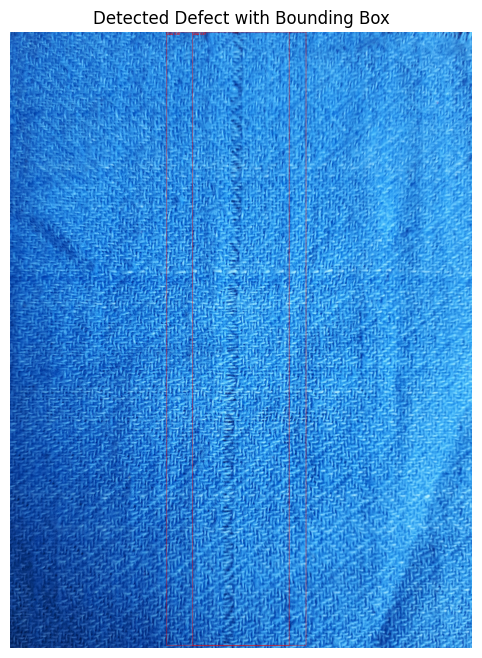

In [26]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/lines/20180531_140329.jpg"
)


===== FINAL RESULT =====

Detection 1
Defect: Lines
Confidence: 0.8044
Bounding Box: x1=319, y1=269, x2=1040, y2=421
Reason 1: 70%: Constant tension pulses/vibrations.
Reason 2: 25%: Yarn slubs or irregular thickness.
Reason 3: 5%: Rolling vibration in the machine frame.
Suggestion: Check machine mounting; stabilize tension rollers; check yarn.
Machine: Any High-Speed Machine

Detection 2
Defect: Lines
Confidence: 0.4260
Bounding Box: x1=339, y1=273, x2=1040, y2=379
Reason 1: 70%: Constant tension pulses/vibrations.
Reason 2: 25%: Yarn slubs or irregular thickness.
Reason 3: 5%: Rolling vibration in the machine frame.
Suggestion: Check machine mounting; stabilize tension rollers; check yarn.
Machine: Any High-Speed Machine

Detection 3
Defect: Lines
Confidence: 0.3427
Bounding Box: x1=323, y1=269, x2=795, y2=396
Reason 1: 70%: Constant tension pulses/vibrations.
Reason 2: 25%: Yarn slubs or irregular thickness.
Reason 3: 5%: Rolling vibration in the machine frame.
Suggestion: Check mac

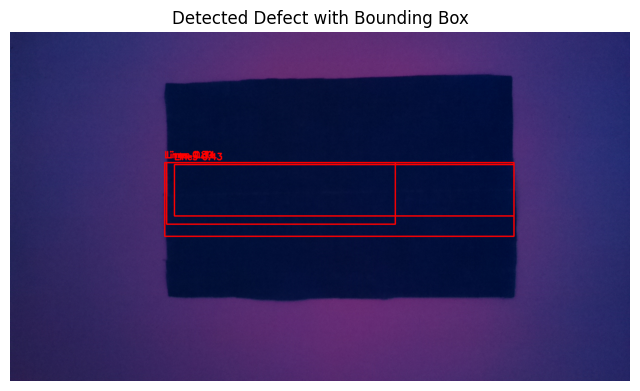

In [27]:
full_prediction_yolo_detection(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/lines/line_2018-10-10 09_49_24.116093.jpg"
)
